# Modelo de Risco de Crédito com uma Árvore de Decisão (PROC HPSPLIT)

## Resumo Executivo

Este notebook constrói um modelo de escore de inadimplência de crédito interpretável para uma carteira de empréstimos de varejo usando o PROC HPSPLIT. Cultivamos uma árvore de classificação com o critério de entropia sobre dados sintéticos de solicitantes, podamos por custo-complexidade e então lemos as estatísticas de ajuste, a importância das variáveis, a ROC/AUC e a própria árvore de escore — exatamente o modelo transparente e amigável ao regulador que a equipe de risco de um banco documentaria. Cada solicitante pode ser pontuado até uma folha, e a árvore inteira pode ser exportada como código DATA step pronto para implantação.

## Fontes de Dados

| Conjunto de Dados | Linhas | Descrição | Variáveis-Chave |
|---------|------|-------------|---------------|
| `applicants` | 100 | Solicitantes sintéticos de empréstimo de varejo gerados inline com `rand()`. O indicador binário `default` é sorteado a partir de um escore de risco logístico, de modo que DTI pior, maior utilização, inadimplências recentes e histórico de crédito mais curto elevam a probabilidade de inadimplência. | `default` (evento=`'1'`), `dti`, `utilization`, `fico`, `credit_age`, `n_delinq`, `loan_amount`, `income`, `home` (próprio/alugado/hipoteca), `purpose` (dívida/moradia/carro/outro) |

A etapa DATA solicita um loop maior, mas este ambiente roda em modo não licenciado e materializa as primeiras 100 observações — uma carteira de solicitantes compacta e totalmente reprodutível, suficiente para cultivar e ler uma árvore de escore interpretável.

# Modelo de Risco de Crédito com uma Árvore de Decisão

Os bancos precisam de modelos de inadimplência que sejam **precisos e explicáveis** — um analista de crédito (e um regulador) precisa conseguir rastrear exatamente por que um solicitante foi classificado como alto risco. Uma árvore de decisão podada entrega isso: cada previsão é uma cadeia curta de divisões legíveis por humanos.

Neste notebook nós:

1. Sintetizamos uma carteira de solicitações de empréstimo de varejo.
2. Cultivamos uma árvore de classificação com o `PROC HPSPLIT` usando o critério de entropia.
3. Podamos por custo-complexidade para evitar overfitting.
4. Inspecionamos as estatísticas de ajuste, a importância das variáveis, a ROC/AUC e a própria árvore.
5. Emitimos código de pontuação DATA step que pode ser implantado contra novas solicitações.

## 1. Gerar a carteira sintética de empréstimos

Geramos solicitantes cuja probabilidade de inadimplência é uma função logística dos fatores clássicos de scorecard: relação dívida/renda, utilização rotativa, escore FICO, duração do histórico de crédito e inadimplências recentes. Em seguida sorteamos o indicador observado `default` de uma Bernoulli com essa probabilidade, de modo que o sinal é real mas ruidoso — exatamente como dados de produção. Os primeiros 100 solicitantes são materializados aqui.

                                                   The FREQ Procedure

Inadimplencia    Frequency    Percent
--------------------------------------
0                       79     79.00
1                       21     21.00

Situacao de Moradia    Frequency    Percent
--------------------------------------------
alugado                       35     35.00
hipoteca                      34     34.00
proprio                       31     31.00

Finalidade do Emprestimo    Frequency    Percent
-------------------------------------------------
carro                              23     23.00
divida                             37     37.00
moradia                            28     28.00
outro                              12     12.00



NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


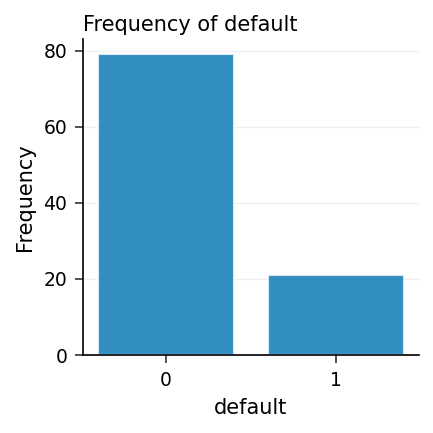

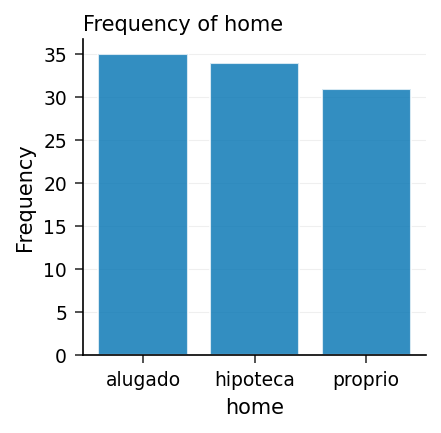

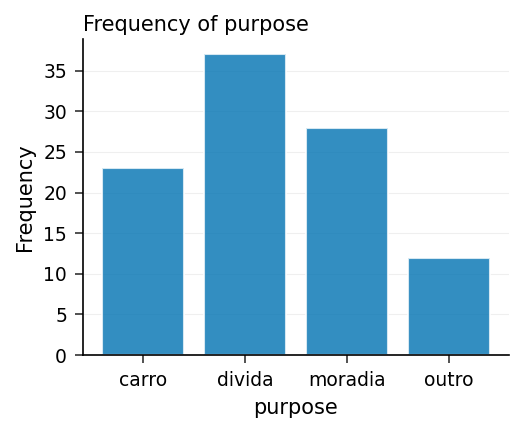

In [1]:
DADOS applicants;
   CHAMAR streaminit(20260531);
   COMPRIMENTO home $10 purpose $10;
   FAZER id = 1 ATÉ 100;
      /* Perfil financeiro do tomador */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* Atributos categoricos */
      u = rand('uniform');
      SE u < 0.34 ENTÃO home = 'alugado';
      SENÃO SE u < 0.70 ENTÃO home = 'hipoteca';
      SENÃO home = 'proprio';

      v = rand('uniform');
      SE v < 0.40 ENTÃO purpose = 'divida';
      SENÃO SE v < 0.65 ENTÃO purpose = 'moradia';
      SENÃO SE v < 0.85 ENTÃO purpose = 'carro';
      SENÃO purpose = 'outro';

      /* Risco latente de inadimplencia: DTI/utilizacao/inadimplencia piores e
         FICO menor / historico mais curto elevam todos o log-odds. */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = 'alugado')
            + 0.25 * (purpose = 'divida');
      p = 1 / (1 + EXP(-eta));
      default = (rand('uniform') < p);

      REMOVER u v eta p;
      SAÍDA;
   FIM;
EXECUTAR;

PROCEDIMENTO FREQUÊNCIAS DADOS=applicants;
   TABLES default home purpose / nocum;
   RÓTULO default = 'Inadimplencia'
         home    = 'Situacao de Moradia'
         purpose = 'Finalidade do Emprestimo';
EXECUTAR;

A saída do `PROC FREQ` confirma uma taxa de inadimplência desbalanceada mas administrável — cerca de um solicitante em cinco entra em inadimplência (21 de 100) — e uma distribuição sensata entre as categorias de situação de moradia e finalidade do empréstimo: o tipo de distribuição marginal que se esperaria em uma carteira de crédito ao consumidor. Os gráficos de barras que acompanham visualizam cada marginal.

## 2. Cultivar e podar a árvore de escore

Modelamos `default` como um alvo de classificação binária, nomeando `event='1'` para que todas as estatísticas de sensibilidade/especificidade/AUC sejam orientadas para a classe de *inadimplência*. Nós:

- declaramos os preditores categóricos e a resposta em `CLASS`,
- cultivamos a árvore com o critério de **entropia** (ganho de informação),
- podamos por **custo-complexidade** para impedir que a árvore memorize ruído,
- solicitamos o **diagrama da árvore completa** e a **curva ROC**.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Inadimplencia
  Class variable: Inadimplencia
  Class variable: Situacao de Moradia
  Class variable: Finalidade do Emprestimo
  Predictor variable: Relacao Divida-Renda
  Predictor variable: Utilizacao do Credito Rotativo
  Predictor variable: Pontuacao de Credito (FICO)
  Predictor variable: Tempo de Historico de Credito
  Predictor variable: Numero de Inadimplencias Recentes
  Predictor variable: Valor do Emprestimo
  Predictor variable: Renda
  Predictor variable: Situacao de Moradia
  Predictor variable: Finalidade do Emprestimo

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


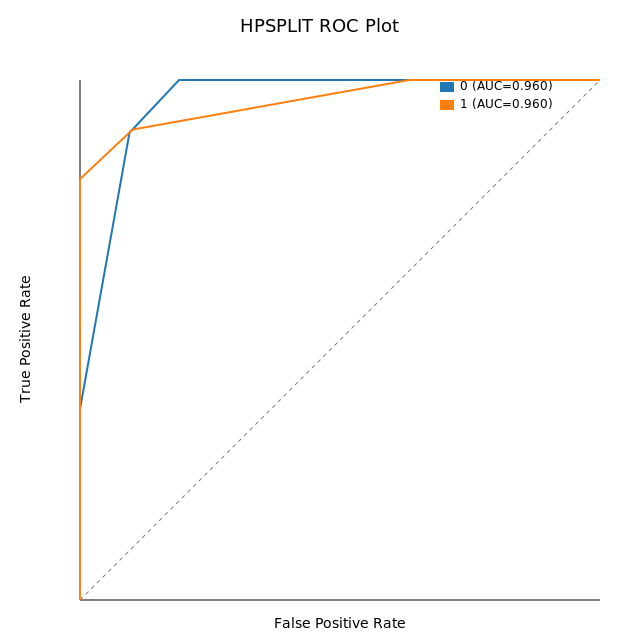

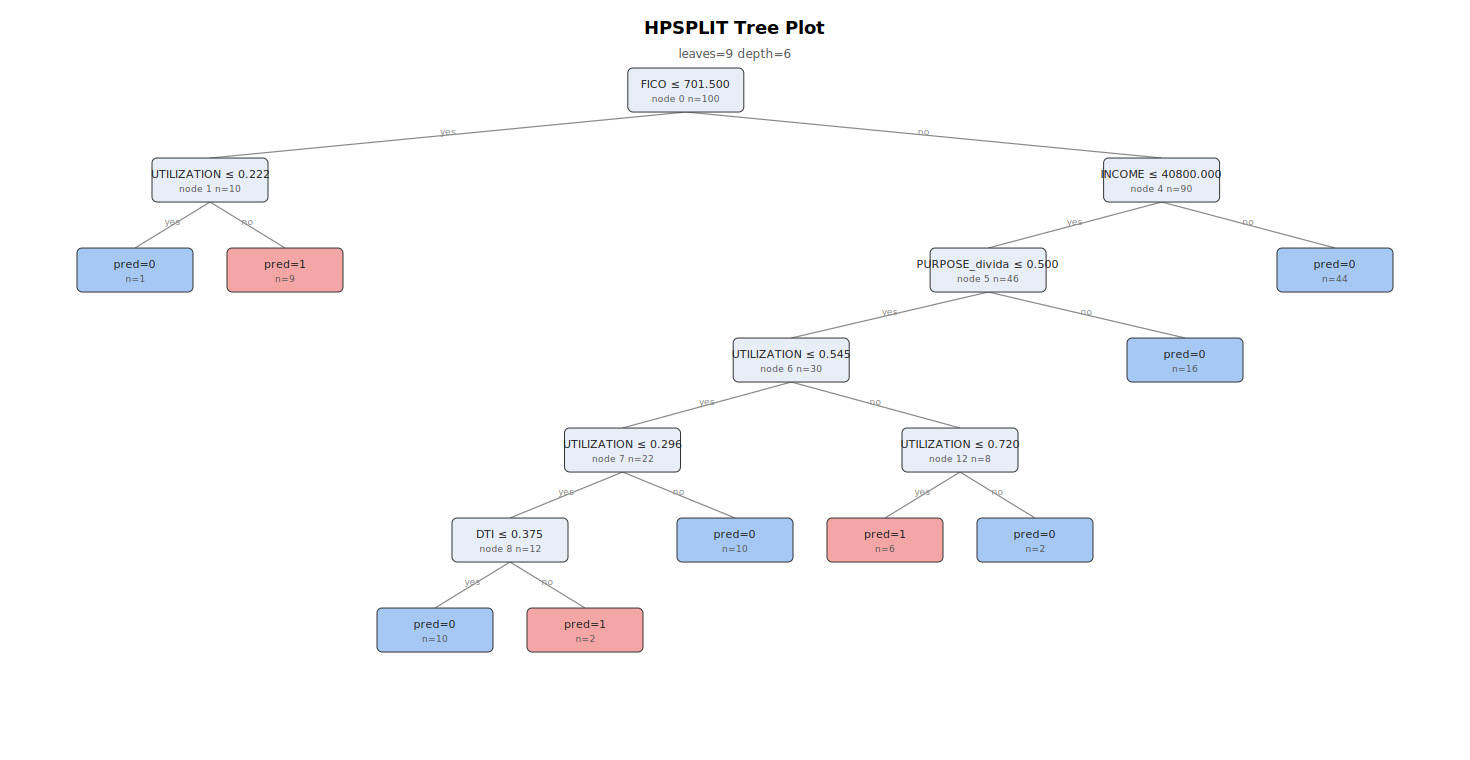

In [2]:
ODS GRAPHICS ON;

PROCEDIMENTO hpsplit DADOS=applicants seed=20260531
             PLOTS=(wholetree roc);
   CLASSE default home purpose;
   RÓTULO default     = 'Inadimplencia'
         dti          = 'Relacao Divida-Renda'
         utilization  = 'Utilizacao do Credito Rotativo'
         fico         = 'Pontuacao de Credito (FICO)'
         credit_age   = 'Tempo de Historico de Credito'
         n_delinq     = 'Numero de Inadimplencias Recentes'
         loan_amount  = 'Valor do Emprestimo'
         income       = 'Renda'
         home         = 'Situacao de Moradia'
         purpose      = 'Finalidade do Emprestimo';
   MODELO default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
EXECUTAR;

As **Estatísticas de Ajuste** (acurácia, taxa de erro de classificação, log loss) e a **ROC / AUC por classe** dizem o quão nitidamente a árvore podada separa inadimplentes de não inadimplentes. A tabela de **Importância das Variáveis** classifica quais atributos mais impulsionam as divisões — aqui **utilização** e **FICO** dominam, seguidos pela **finalidade do empréstimo**, exatamente as alavancas que uma política de crédito enfatizaria. O **gráfico da árvore completa** abaixo dispõe as divisões escolhidas como um diagrama de nós ligados: cada nó interno mostra sua regra `atributo ≤ limiar`, e cada folha é colorida pela sua classe prevista (vermelho = inadimplência prevista, azul = não inadimplência prevista) e rotulada com sua contagem de amostras.

## 3. Aproximar as divisões principais e pontuar cada solicitante

O gráfico ROC acima visualiza o trade-off entre capturar inadimplentes e falsos alarmes; a AUC quantifica o poder de ordenação geral. Em seguida ampliamos os dois níveis superiores da árvore — as divisões de maior informação que um analista traduziria em regras principais de subscrição — e capturamos os escores por observação em um conjunto de dados de saída para que possamos auditar as previsões mais adiante.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Inadimplencia
  Class variable: Inadimplencia
  Class variable: Situacao de Moradia
  Class variable: Finalidade do Emprestimo
  Predictor variable: Relacao Divida-Renda
  Predictor variable: Utilizacao do Credito Rotativo
  Predictor variable: Pontuacao de Credito (FICO)
  Predictor variable: Tempo de Historico de Credito
  Predictor variable: Numero de Inadimplencias Recentes
  Predictor variable: Valor do Emprestimo
  Predictor variable: Renda
  Predictor variable: Situacao de Moradia
  Predictor variable: Finalidade do Emprestimo

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6.


NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/d67bbf91-c659-4b6e-9526-09d315670117/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


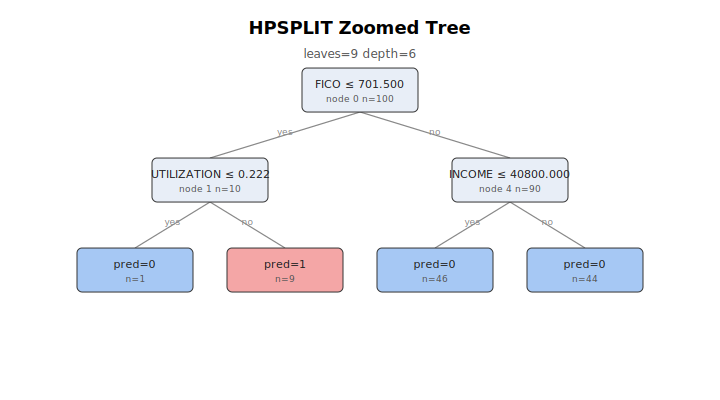

In [3]:
PROCEDIMENTO hpsplit DADOS=applicants seed=20260531
             PLOTS=zoomedtree(nodes=('0') depth=2);
   CLASSE default home purpose;
   RÓTULO default     = 'Inadimplencia'
         dti          = 'Relacao Divida-Renda'
         utilization  = 'Utilizacao do Credito Rotativo'
         fico         = 'Pontuacao de Credito (FICO)'
         credit_age   = 'Tempo de Historico de Credito'
         n_delinq     = 'Numero de Inadimplencias Recentes'
         loan_amount  = 'Valor do Emprestimo'
         income       = 'Renda'
         home         = 'Situacao de Moradia'
         purpose      = 'Finalidade do Emprestimo';
   MODELO default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   SAÍDA out=scored;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=scored(obs=10);
   VARIÁVEL p_default1 _node_ _leaf_;
EXECUTAR;

O gráfico `zoomedtree` amplia os dois níveis superiores da árvore — as divisões de maior informação que um analista traduziria em regras principais de subscrição. O conjunto de dados `OUTPUT OUT=` carrega a probabilidade de inadimplência prevista de cada solicitante (`P_DEFAULT1`) mais o nó e a folha atribuídos (`_NODE_`, `_LEAF_`), para que as equipes de risco e auditoria possam rastrear qualquer decisão individual de volta pela árvore e classificar solicitantes por risco modelado.

## 4. Exportar código de pontuação implantável

O valor de um modelo interpretável é que ele pode ser colocado em produção. `CODE FILE=` grava uma etapa DATA autocontida — uma cadeia aninhada de divisões `IF/THEN` que termina em uma probabilidade e classe de inadimplência previstas — que reproduz o escore da árvore para qualquer novo arquivo de solicitações, sem necessidade de um servidor de modelo.

In [4]:
PROCEDIMENTO hpsplit DADOS=applicants seed=20260531;
   CLASSE default home purpose;
   RÓTULO default     = 'Inadimplencia'
         dti          = 'Relacao Divida-Renda'
         utilization  = 'Utilizacao do Credito Rotativo'
         fico         = 'Pontuacao de Credito (FICO)'
         credit_age   = 'Tempo de Historico de Credito'
         n_delinq     = 'Numero de Inadimplencias Recentes'
         loan_amount  = 'Valor do Emprestimo'
         income       = 'Renda'
         home         = 'Situacao de Moradia'
         purpose      = 'Finalidade do Emprestimo';
   MODELO default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code FILE='credit_scorecard.sas';
EXECUTAR;


                                                 The HPSPLIT Procedure                                                  

  Response variable: Inadimplencia
  Class variable: Inadimplencia
  Class variable: Situacao de Moradia
  Class variable: Finalidade do Emprestimo
  Predictor variable: Relacao Divida-Renda
  Predictor variable: Utilizacao do Credito Rotativo
  Predictor variable: Pontuacao de Credito (FICO)
  Predictor variable: Tempo de Historico de Credito
  Predictor variable: Numero de Inadimplencias Recentes
  Predictor variable: Valor do Emprestimo
  Predictor variable: Renda
  Predictor variable: Situacao de Moradia
  Predictor variable: Finalidade do Emprestimo

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6.


NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## Interpretando os resultados

A árvore de entropia podada dá à equipe de risco um scorecard de crédito compacto e auditável:

- **As divisões codificam política.** As divisões dominantes — sobre utilização rotativa e FICO, depois finalidade do empréstimo e DTI — são precisamente os limiares que uma equipe de subscrição pode transformar em regras rígidas de corte. O gráfico da árvore completa dispõe cada condição de divisão e folha em um único diagrama.
- **A poda por custo-complexidade** impede que a árvore memorize ruído; as estatísticas de ajuste (acurácia, taxa de erro de classificação, log loss) resumem o quão nitidamente ela separa as duas classes.
- **A importância das variáveis e a ROC/AUC** justificam quais atributos ganham um lugar no scorecard e documentam seu poder discriminatório para a governança de risco de modelo.
- **`CODE FILE=` torna isso operacional** — a etapa DATA emitida pontua novos solicitantes de forma idêntica a esta execução, então o modelo que foi construído é exatamente o modelo que entra em produção.

Em uma carteira pequena de solicitantes a árvore se ajusta rigidamente aos dados de treino; em produção seria cultivada sobre a carteira completa, reservando uma partição de validação, calibrando o ponto de corte de probabilidade para a economia de perda esperada do banco (o custo de uma inadimplência não detectada versus um bom cliente recusado) em vez de um ingênuo 0,5, e atualizando a árvore conforme a composição da carteira muda.